In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

project_root = os.path.dirname(os.path.abspath(''))
if project_root not in sys.path:
    sys.path.append(project_root)

from MODELS.xgboostModel import *
from MODELS.NGBoostModel import *
from PRODUCTION.pipeline import *

c:\Users\alexg\OneDrive\Documents\NBA-Prop-Predictor\nba_model\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [20]:

pd.set_option('display.max_columns', None)

s19 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_19.csv')
s20 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_20.csv')
s21 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_21.csv')
s22 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_22.csv')
s23 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_23.csv')
s24 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_24.csv')
s25 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_25.csv')
s26 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_26.csv')


# Backtesting Training data
train_df = pd.concat([s19,s20,s21,s22,s23,s24,s25])
train_df = train_df[(train_df['MIN'] > 12)]

# Backtesting Validation data
val_df = s26
val_df = val_df[(val_df['MIN'] > 12)]


print(f"Train set: {len(train_df)} samples")
print(f"Val set: {len(val_df)} samples")

train_df.sample(5)

C:\Users\alexg\AppData\Local\Temp\ipykernel_36100\3162106963.py:10: DtypeWarning: Columns (33) have mixed types. Specify dtype option on import or set low_memory=False.
  s26 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_26.csv')


Train set: 143859 samples
Val set: 3248 samples


,Unnamed: 0,Unnamed: 0.2,PLAYER_NAME,PLAYER_ID,MATCHUP,TEAM_ABBREVIATION,TEAM_ID,OPP_ABBREVIATION,HOME_GAME,GAME_ID,GAME_DATE,WL,PTS,AST,REB,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,FTA,FT_PCT,OREB,DREB,STL,BLK,TOV,PLUS_MINUS,FANTASY_PTS,POINT_PER_SHOT,EFG,START_POSITION,COMMENT,OFF_RATING,E_OFF_RATING,DEF_RATING,E_DEF_RATING,NET_RATING,OREB_PCT,DREB_PCT,REB_PCT,AST_PCT,EFG_PCT,AST_TOV,USG_PCT,TS_PCT,E_PACE,PACE,PIE,POSS,PACE_PER40,E_USG_PCT,MIN,SPD,DIST,ORBC,DRBC,RBC,TCHS,SAST,FTAST,PASS,CFGM,CFGA,CFG_PCT,UFGM,UFGA,UFG_PCT,DFGM,DFGA,DFG_PCT,PTS_OFF_TOV,PTS_2ND_CHANCE,PTS_FB,PTS_PAINT,OPP_PTS_OFF_TOV,OPP_PTS_2ND_CHANCE,OPP_PTS_FB,OPP_PTS_PAINT,BLKA,PF,PFD,IS_PLAYOFF,TEAM_NAME,TEAM_MIN,TEAM_FGM,TEAM_FGA,TEAM_FG_PCT,TEAM_FG3M,TEAM_FG3A,TEAM_FG3_PCT,TEAM_FTM,TEAM_FTA,TEAM_FT_PCT,TEAM_OREB,TEAM_DREB,TEAM_REB,TEAM_AST,TEAM_STL,TEAM_BLK,TEAM_TOV,TEAM_PF,TEAM_PTS,TEAM_PLUS_MINUS,TEAM_PACE,GAME_PACE,OPP_PACE,OPP_TEAM_ID,TEAM_OFF_RATING,TEAM_DEF_RATING,OPP_DEF_RATING,OPP_OFF_RATING,OPP_PTS,OPP_FGM,OPP_FGA,OPP_FG_PCT,OPP_REB,OPP_AST,OPP_STL,OPP_BLK,OPP_TOV,whos_favored,spread,total,team_is_favored,team_spread,percentageFieldGoalsAttempted2pt,percentageFieldGoalsAttempted3pt,percentagePoints2pt,percentagePointsMidrange2pt,percentagePoints3pt,percentagePointsFastBreak,percentagePointsFreeThrow,percentagePointsOffTurnovers,percentagePointsPaint,percentageAssisted2pt,percentageUnassisted2pt,percentageAssisted3pt,percentageUnassisted3pt,percentageAssistedFGM,percentageUnassistedFGM,GP,AGE,FREQ_FG3,FG3M_main,FG3A_main,FG3_PCT_main,NS_FG3_PCT,PLUS_MINUS_FG3,FREQ_FG2,FG2M,FG2A,FG2_PCT,NS_FG2_PCT,PLUS_MINUS_FG2,FREQ_LT_06,FGM_LT_06,FGA_LT_06,LT_06_PCT,NS_LT_06_PCT,PLUS_MINUS_LT_06,FREQ_LT_10,FGM_LT_10,FGA_LT_10,LT_10_PCT,NS_LT_10_PCT,PLUS_MINUS_LT_10,FREQ_GT_15,FGM_GT_15,FGA_GT_15,GT_15_PCT,NS_GT_15_PCT,PLUS_MINUS_GT_15,matchupFieldGoalsMade,matchupFieldGoalsAttempted,matchupThreePointersMade,matchupThreePointersAttempted,playerPoints,matchupMinutes,DEF_FG_PCT_ALLOWED,DEF_3PT_PCT_ALLOWED,PTS_ALLOWED_PER_MIN,DEF_TOV_FORCED_PER_MIN,DEF_BLOCKS_PER_MIN,DEF_SHOOTING_FOULS_PER_MIN,DEF_AST_ALLOWED_PER_MIN,STARTING,GAMES_THIS_SEASON,HEIGHT,WEIGHT,GUARD,FORWARD,CENTER,TEAM_DAYS_REST,PLAYER_DAYS_REST,TEAM_B2B,IS_BACK_TO_BACK,PLAYER_MISSED_LAST,PTS_ROLLING_AVG_5,AST_ROLLING_AVG_5,FGM_ROLLING_AVG_5,FGA_ROLLING_AVG_5,FG_PCT_ROLLING_AVG_5,FG3M_ROLLING_AVG_5,FG3A_ROLLING_AVG_5,FG3_PCT_ROLLING_AVG_5,FTA_ROLLING_AVG_5,FTM_ROLLING_AVG_5,FT_PCT_ROLLING_AVG_5,TOV_ROLLING_AVG_5,TS_PCT_ROLLING_AVG_5,USG_PCT_ROLLING_AVG_5,MIN_ROLLING_AVG_5,PACE_ROLLING_AVG_5,PIE_ROLLING_AVG_5,E_OFF_RATING_ROLLING_AVG_5,NET_RATING_ROLLING_AVG_5,TCHS_ROLLING_AVG_5,POSS_ROLLING_AVG_5,EFG_PCT_ROLLING_AVG_5,percentagePointsPaint_ROLLING_AVG_5,percentagePointsMidrange2pt_ROLLING_AVG_5,percentagePoints3pt_ROLLING_AVG_5,PTS_ROLLING_AVG_10,AST_ROLLING_AVG_10,FGM_ROLLING_AVG_10,FGA_ROLLING_AVG_10,FG_PCT_ROLLING_AVG_10,FG3M_ROLLING_AVG_10,FG3A_ROLLING_AVG_10,FG3_PCT_ROLLING_AVG_10,FTA_ROLLING_AVG_10,FTM_ROLLING_AVG_10,FT_PCT_ROLLING_AVG_10,TOV_ROLLING_AVG_10,TS_PCT_ROLLING_AVG_10,USG_PCT_ROLLING_AVG_10,MIN_ROLLING_AVG_10,PACE_ROLLING_AVG_10,PIE_ROLLING_AVG_10,E_OFF_RATING_ROLLING_AVG_10,NET_RATING_ROLLING_AVG_10,TCHS_ROLLING_AVG_10,POSS_ROLLING_AVG_10,EFG_PCT_ROLLING_AVG_10,percentagePointsPaint_ROLLING_AVG_10,percentagePointsMidrange2pt_ROLLING_AVG_10,percentagePoints3pt_ROLLING_AVG_10,PTS_ROLLING_AVG_20,AST_ROLLING_AVG_20,FGM_ROLLING_AVG_20,FGA_ROLLING_AVG_20,FG_PCT_ROLLING_AVG_20,FG3M_ROLLING_AVG_20,FG3A_ROLLING_AVG_20,FG3_PCT_ROLLING_AVG_20,FTA_ROLLING_AVG_20,FTM_ROLLING_AVG_20,FT_PCT_ROLLING_AVG_20,TOV_ROLLING_AVG_20,TS_PCT_ROLLING_AVG_20,USG_PCT_ROLLING_AVG_20,MIN_ROLLING_AVG_20,PACE_ROLLING_AVG_20,PIE_ROLLING_AVG_20,E_OFF_RATING_ROLLING_AVG_20,NET_RATING_ROLLING_AVG_20,TCHS_ROLLING_AVG_20,POSS_ROLLING_AVG_20,EFG_PCT_ROLLING_AVG_20,percentagePointsPaint_ROLLING_AVG_20,percentagePointsMidrange2pt_ROLLING_AVG_20,percentagePoints3pt_ROLLING_AVG_20,PTS_ROLLING_AVG_40,AST_ROLLING_AVG_40,FGM_ROLLING

In [ ]:
enhanced_top_features = [
    # ===== CORE CONTEXT =====
    'HOME_GAME',
    'STARTING',
    'PLAYER_IS_TEAM_STAR',
    'STAR_SAT_OUT',
    'PLAYER_DAYS_REST',
    'USUAL_STARTERS_AVAILABLE',
    'OPP_USUAL_STARTERS_AVAILABLE',
    'GAMES_PLAYED_TO_DATE',
    
    # ===== ROLLING AVERAGES =====
    'PTS_ROLLING_AVG_5', #new
    'PTS_ROLLING_AVG_10',
    'PTS_ROLLING_AVG_20', #new
    'MIN_ROLLING_AVG_5', #new
    'MIN_ROLLING_AVG_10',
    'MIN_ROLLING_AVG_20', #new
    'USG_PCT_ROLLING_AVG_5', #new
    'USG_PCT_ROLLING_AVG_10',
    'USG_PCT_ROLLING_AVG_20', #new
    'TS_PCT_ROLLING_AVG_10',
    'TS_PCT_ROLLING_AVG_20', #new
    'FGA_ROLLING_AVG_5', #new
    'FGA_ROLLING_AVG_10', #new
    'FGA_ROLLING_AVG_20', #new
    'FG_PCT_ROLLING_AVG_10',
    'FG_PCT_ROLLING_AVG_20', #new
    'FG3A_ROLLING_AVG_5', #new
    'FG3A_ROLLING_AVG_10', #new
    'FG3A_ROLLING_AVG_20', #new
    'FG3_PCT_ROLLING_AVG_10', #new
    'FG3_PCT_ROLLING_AVG_20', #new
    'FTA_ROLLING_AVG_5', #new
    'FTA_ROLLING_AVG_10', #new
    'FTA_ROLLING_AVG_20', #new
    'FT_PCT_ROLLING_AVG_10', #new
    'FT_PCT_ROLLING_AVG_20', #new
    'E_OFF_RATING_ROLLING_AVG_5',
    'E_OFF_RATING_ROLLING_AVG_10',
    'E_OFF_RATING_ROLLING_AVG_20', #new
    'NET_RATING_ROLLING_AVG_5', #new
    'NET_RATING_ROLLING_AVG_10',
    'NET_RATING_ROLLING_AVG_20', #new

    # ===== LAG FEATURES =====
    'MIN_LAG_1',
    'PTS_LAG_1',
    'FGA_LAG_1',
    'USG_PCT_LAG_1',
    
    # ===== VOLATILITY =====
    'MIN_VOLATILITY_5_TO_DATE',
    'MIN_VOLATILITY_10_TO_DATE',
    'MIN_VOLATILITY_20_TO_DATE', #new
    'PTS_VOLATILITY_5_TO_DATE',
    'PTS_VOLATILITY_10_TO_DATE', #new
    'PTS_VOLATILITY_20_TO_DATE', #new
    'FGA_VOLATILITY_5_TO_DATE',
    'FGA_VOLATILITY_10_TO_DATE',
    'FGA_VOLATILITY_20_TO_DATE',
    'USG_PCT_CV_5_TO_DATE',
    'USG_PCT_CV_10_TO_DATE', #new
    'USG_PCT_CV_20_TO_DATE', #new
    'TS_PCT_CV_10_TO_DATE',
    'TS_PCT_CV_20_TO_DATE', #new
    'FG3A_VOLATILITY_5_TO_DATE',
    'FG3A_VOLATILITY_10_TO_DATE', #new
    'FG3A_VOLATILITY_20_TO_DATE', #new
    'FG3_PCT_CV_10_TO_DATE',
    'FG3_PCT_CV_20_TO_DATE', #new
    'FTA_VOLATILITY_5_TO_DATE',
    'FTA_VOLATILITY_10_TO_DATE', #new
    'FTA_VOLATILITY_20_TO_DATE', #new
    'FT_PCT_CV_10_TO_DATE',
    'FT_PCT_CV_20_TO_DATE', #new
    'TOV_VOLATILITY_10_TO_DATE',
    'PACE_VOLATILITY_5_TO_DATE',
    'PACE_VOLATILITY_10_TO_DATE',
    'E_OFF_RATING_VOLATILITY_5_TO_DATE',
    'E_OFF_RATING_VOLATILITY_10_TO_DATE',
    'NET_RATING_VOLATILITY_5_TO_DATE',
    'NET_RATING_VOLATILITY_10_TO_DATE',
    'TCHS_ROLLING_AVG_5', #new
    'TCHS_ROLLING_AVG_10',
    'TOV_ROLLING_AVG_5', #new
    'TOV_ROLLING_AVG_10',

    # ===== MIN/MAX (Useful extremes) =====
    'MIN_MAX_LAST_10', 
    'MIN_MIN_LAST_10',
    'PTS_MIN_LAST_10',
    'USG_PCT_MAX_LAST_10',
    'USG_PCT_MIN_LAST_10',
    'PTS_RANGE_10', #new
    'USG_PCT_RANGE_10', #new
    'TS_PCT_RANGE_10', #new
    
    # ==== Short vs long term divergences =====
    'PTS_5G_VS_20G_RATIO', #new
    'MIN_5G_VS_20G_RATIO', #new
    'USG_PCT_5G_VS_20G_RATIO', #new
    
    # === Consistency metrics =====
    'PTS_CONSISTENCY', #new
    'MIN_CONSISTENCY', #new
    'USG_PCT_CONSISTENCY', #new
    
    # === Variance stability metrics =====
    'VARIANCE_STABILITY', #new
    'MIN_VARIANCE_STABILITY', #new
    'USG_PCT_VARIANCE_STABILITY', #new
    'TS_PCT_VARIANCE_STABILITY', #new
    
    # ===== TRENDS =====
    'PTS_TREND_LAST_5',
    'MIN_TREND_LAST_5',
    'PTS_TREND_LAST_10',
    'MIN_TREND_LAST_10',
    
    # ===== INTERACTIONS (Keep - your best features) =====
    'PTS_X_STAR_PLAYER',
    'NET_RATING_X_STAR_PLAYER',
    'PTS_PER_MIN_X_USG',
    'USAGE_X_EFFICIENCY',
    'PTS_PER_POSSESSION',
    
    # ===== SHOT PROFILE =====
    'percentagePointsMidrange2pt_AVG_TO_DATE',
    'percentagePointsPaint_AVG_TO_DATE',
    '3PA_RATE',
    'PLAYER_FG3A_SHARE',
    'PTS_PER_SHOT', #new
    
    # ===== STAR DYNAMICS =====
    'PTS_DELTA_STAR_OUT',
    'USG_PCT_DELTA_STAR_OUT',
    'MIN_DELTA_STAR_OUT', #new
    'FGA_DELTA_STAR_OUT', #new
    
    # ===== STREAKS & TIERS =====
    'IS_LOW_SCORER',
    'IS_MEDIUM_SCORER',
    'IS_HIGH_SCORER', #new
    
    
    # ===== TEAM CONTEXT =====
    'TEAM_PTS_ROLLING_AVG_3', 
    'TEAM_OFF_RATING_ROLLING_AVG_3', 
    'TEAM_OFF_RATING_AVG_TO_DATE',
    'TEAM_PACE_AVG_TO_DATE',
    'TEAM_DEF_RATING_ROLLING_AVG_3',
    
    # ===== OPPONENT =====
    'OPP_DEF_RATING_AVG_TO_DATE',
    'OPP_PACE_AVG_TO_DATE',
    'OPP_TOV_AVG_TO_DATE',
    'OPP_GUARD_DEF_RATING',
    'OPP_FORWARD_DEF_RATING',
    'OPP_CENTER_DEF_RATING',
    
    # ===== MATCHUP INTERACTIONS =====
    'PLAYER_X_MATCHUP_GUARD_FG_PCT',
    'PLAYER_3PT_RATE_X_OPP_GUARD_3PT_DEF_ALLOWED',
    'OPP_GUARD_PTS_ALLOWED_PER_MIN',
    'PLAYER_X_MATCHUP_FORWARD_FG_PCT',
    'PLAYER_3PT_RATE_X_OPP_FORWARD_3PT_DEF_ALLOWED',
    'OPP_FORWARD_PTS_ALLOWED_PER_MIN',
    'PLAYER_X_MATCHUP_CENTER_FG_PCT',
    'PLAYER_3PT_RATE_X_OPP_CENTER_3PT_DEF_ALLOWED',
    'OPP_CENTER_PTS_ALLOWED_PER_MIN',
    
    # ===== GAME CONTEXT =====
    'TEAM_OFF_MINUS_OPP_DEF',
    'EXPECTED_PACE',
    'PACE_DIFFERENTIAL',
    
    # ===== HOME/AWAY & MATCHUP =====
    'PLAYER_HOME_PTS_DELTA',
    'PLAYER_HOME_USG_PCT_DELTA',
    'PLAYER_HOME_FGA_DELTA',
    'PLAYER_HOME_FTA_DELTA',
    'MATCHUP_AVG_PTS_TO_DATE',
    'MATCHUP_AVG_MIN_TO_DATE',
    'MATCHUP_AVG_USG_PCT_TO_DATE',
    'MATCHUP_AVG_TS_PCT_TO_DATE',
]
print(f"Enhanced features: {len(enhanced_top_features)}")

Enhanced features: 110


In [ ]:
# columns = train_df.columns.tolist()
# guardIDX = columns.index('GUARD')
# features = columns[guardIDX + 1:]
# numeric_columns = train_df.select_dtypes(include=[np.number]).columns.tolist()
# features = [col for col in features if col in numeric_columns]
# newFeatures = features

In [ ]:
# from MODELS.xgboostModel import *

# selected_features, top_features = select_features_xgb_importance(
#     train_df[newFeatures],
#     train_df['PTS'],
#     top_n=60,                 # increase if you want more coverage
#     n_runs=5,                 # stabilizes importance ranking
#     include_context=False,     # adds game context
#     validate_permutation=False # prunes noise
# )

# XGBOOST MODEL

### Remove correlated features

In [4]:
from MODELS.xgboostModel import *
# corr_matrix, top_10_features = correlation_analysis(train_df, top_features)

# final_features = remove_highly_correlated_features(train_df, top_features, threshold=0.90)
final_features = remove_highly_correlated_features(train_df, enhanced_top_features, threshold=0.90)

REMOVED: PLAYER_IS_TEAM_STAR            (corr with PTS_X_STAR_PLAYER: 0.964)

SUMMARY:
Original features: 123
Removed features: 1
Final features: 122


### NGBOOST MODEL

SPLIT NGBOOST

In [22]:

mean_model, variance_model, cal_factor = fit_ngboost_split(
train_df,
val_df,
enhanced_top_features,
target_col='PTS',
distribution=Normal,
player_col='PLAYER_ID',
recent_n=20,
recent_weight=2.0,
variance_recent_weight=1.0,
variance_lr=0.03,  
variance_max_depth=8,  
variance_n_estimators=1000,
variance_calibration_factor=3.97)


Using passed validation data to check for early stopping.
Using passed validation data to check for early stopping.


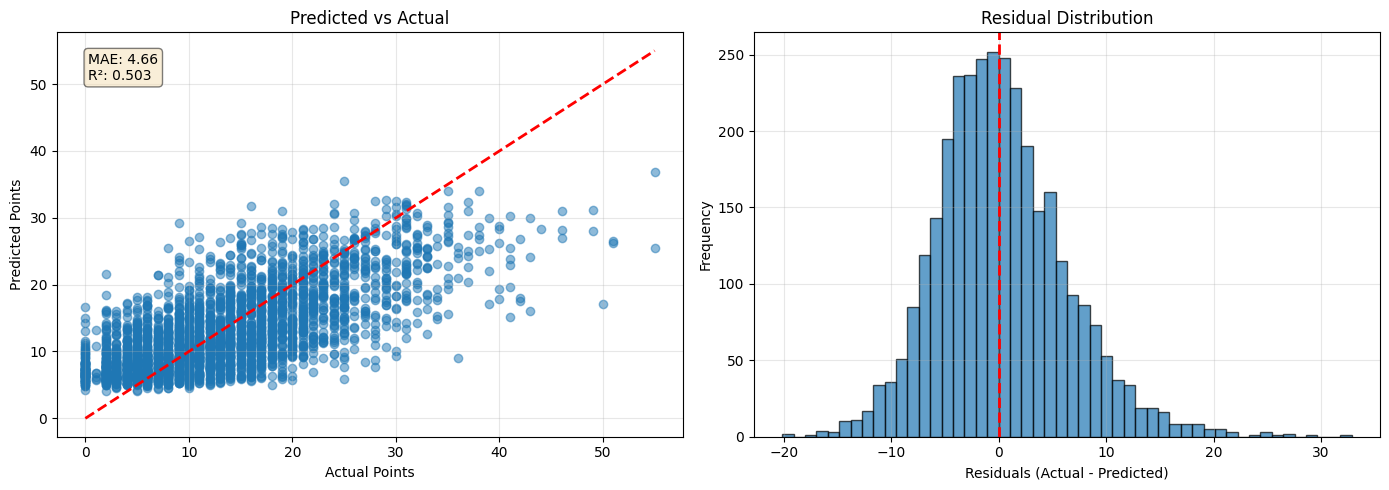

In [23]:
import matplotlib.pyplot as plt


preds_dist = mean_model.pred_dist(val_df[enhanced_top_features])
y_pred_mean = preds_dist.loc
y_pred_std = preds_dist.scale
y_true = val_df['PTS'].values

fig, axes = plt.subplots(1, 2, figsize=(14, 5))


axes[0].scatter(y_true, y_pred_mean, alpha=0.5)
axes[0].plot([y_true.min(), y_true.max()], 
             [y_true.min(), y_true.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Points')
axes[0].set_ylabel('Predicted Points')
axes[0].set_title('Predicted vs Actual')
axes[0].grid(True, alpha=0.3)

mae = mean_absolute_error(y_true, y_pred_mean)
r2 = r2_score(y_true, y_pred_mean)
axes[0].text(0.05, 0.95, f'MAE: {mae:.2f}\nR²: {r2:.3f}', 
             transform=axes[0].transAxes,
             verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

residuals = y_true - y_pred_mean
axes[1].hist(residuals, bins=50, edgecolor='black', alpha=0.7)
axes[1].axvline(x=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Residuals (Actual - Predicted)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Residual Distribution')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [24]:
mean_importance_raw = mean_model.feature_importances_  
var_importance_raw = variance_model.feature_importances_    

# Average across the 2 distributions
mean_importance = mean_importance_raw.mean(axis=0)  
var_importance = var_importance_raw.mean(axis=0)    

# NOW create the DataFrame
feature_importance_df = pd.DataFrame({
    'feature': enhanced_top_features,
    'mean_model': mean_importance,  
    'var_model': var_importance    
}).sort_values('mean_model', ascending=False)

# Display top features
print("\n" + "="*80)
print("TOP 20 FEATURES FOR PREDICTING POINTS (MEAN MODEL)")
print("="*80)
print(feature_importance_df[['feature', 'mean_model']].tail(20).to_string(index=False))


TOP 20 FEATURES FOR PREDICTING POINTS (MEAN MODEL)
                                     feature  mean_model
                      USG_PCT_DELTA_STAR_OUT    0.002190
                   FG3A_VOLATILITY_5_TO_DATE    0.002148
                      FG3_PCT_ROLLING_AVG_10    0.002029
                    FTA_VOLATILITY_5_TO_DATE    0.001986
             PLAYER_X_MATCHUP_FORWARD_FG_PCT    0.001960
                   MIN_VOLATILITY_10_TO_DATE    0.001910
                   NET_RATING_ROLLING_AVG_20    0.001878
                       PLAYER_HOME_FGA_DELTA    0.001734
                       PLAYER_HOME_PTS_DELTA    0.001712
                       TS_PCT_ROLLING_AVG_10    0.001635
                             PTS_CONSISTENCY    0.001617
                         USG_PCT_CONSISTENCY    0.001496
                           TOV_ROLLING_AVG_5    0.001278
                   PTS_VOLATILITY_10_TO_DATE    0.001243
                       USG_PCT_CV_10_TO_DATE    0.001193
                       TS_PCT_ROLLIN

In [25]:
feature_importance_df = pd.DataFrame({
    'feature': enhanced_top_features,
    'mean_model': mean_importance,  
    'var_model': var_importance    
}).sort_values('var_model', ascending=False)


print("\n" + "="*80)
print("TOP 20 FEATURES FOR PREDICTING POINTS (VAR MODEL)")
print("="*80)
print(feature_importance_df[['feature', 'var_model']].tail(20).to_string(index=False))


TOP 20 FEATURES FOR PREDICTING POINTS (VAR MODEL)
                                     feature  var_model
                                PTS_RANGE_10   0.002855
                          PTS_ROLLING_AVG_10   0.002747
                   FG3A_VOLATILITY_5_TO_DATE   0.002744
                          MIN_ROLLING_AVG_10   0.002678
                           TOV_ROLLING_AVG_5   0.002628
                    USUAL_STARTERS_AVAILABLE   0.002511
                          FG3A_ROLLING_AVG_5   0.002469
                           FTA_ROLLING_AVG_5   0.002308
                            PLAYER_DAYS_REST   0.002300
                         FG3A_ROLLING_AVG_20   0.002284
              PLAYER_X_MATCHUP_CENTER_FG_PCT   0.002174
                    NET_RATING_X_STAR_PLAYER   0.001912
PLAYER_3PT_RATE_X_OPP_CENTER_3PT_DEF_ALLOWED   0.001888
                           PTS_X_STAR_PLAYER   0.000895
                            IS_MEDIUM_SCORER   0.000841
                OPP_USUAL_STARTERS_AVAILABLE   0.0007

In [26]:
validate_production_model(mean_model, variance_model, val_df, enhanced_top_features, 'PTS', cal_factor)

=== CALIBRATION CHECK ===
Standardized residuals mean: 0.030 (should be ~0)
Standardized residuals std: 1.008 (should be ~1)
Q25: Predicted=8.7, Actual=6.0
Q50: Predicted=12.7, Actual=11.0
Q75: Predicted=16.7, Actual=18.0

MAE: 4.66
90% CI: Coverage=90.52%, Expected=90.00%
95% CI: Coverage=95.32%, Expected=95.00%
99% CI: Coverage=98.40%, Expected=99.00%


array([-0.7491215 ,  0.40260119,  1.41609653, ...,  0.19361464,
        0.459179  , -0.5478819 ], shape=(3248,))

In [27]:
import joblib

# # Save NGBoost split models (mean, variance, and calibration factor)
joblib.dump(mean_model, 'SAVED_MODELS/NGBOOST_PTS_MEAN_MODEL_PRODUCTION.pkl')
joblib.dump(variance_model, 'SAVED_MODELS/NGBOOST_PTS_VAR_MODEL_PRODUCTION.pkl')
joblib.dump(cal_factor, 'SAVED_MODELS/NGBOOST_PTS_CALIBRATION_FACTOR_PRODUCTION.pkl')

joblib.dump(enhanced_top_features, 'SAVED_MODELS/feature_list.pkl')

['SAVED_MODELS/feature_list.pkl']

In [19]:
import joblib

joblib.dump(mean_model, 'SAVED_MODELS/NGBOOST_PTS_MEAN_MODEL_TEST_25v1.pkl')
joblib.dump(variance_model, 'SAVED_MODELS/NGBOOST_PTS_VAR_MODEL_TEST_25v1.pkl')
joblib.dump(cal_factor, 'SAVED_MODELS/NGBOOST_PTS_CALIBRATION_FACTOR_TEST_25v1.pkl')

joblib.dump(enhanced_top_features, 'SAVED_MODELS/feature_listv1.pkl')

['SAVED_MODELS/feature_listv1.pkl']